In [ ]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
netCDF=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))


In [ ]:
# t=33;
# variable='w'
# wthresh=1

# w_data=netCDF[variable].data

# where=np.where((w_data>=wthresh))
# masked=w_data[where]
# masked

In [ ]:
#Making vertical profile of cloudy updrafts for single timestep
def full_profile(var,type):
    #thresholds
    wthresh=1
    qcqithresh=1e-6

    nt=len(data['time'])
    if np.mod(t,20)==0: print(f'current time is {t}/{nt}') 
        
    #get qc and interpolated w 
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    print('done loading')

    # finds regions that match the threshold
    if type=="general":
        where_updraft=np.where((w_data>=wthresh)) #uncomment for "general updraft"
    elif type=='cloudy': 
        where_updraft=np.where((w_data>=wthresh) & (qc_plus_qi>=qcqithresh)) #uncomment for "cloudy updraft" 
    
    #creates profile storage and adds z column    
    zhs=data['zh'].values
    profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs

    #get incidies associated with threshold mask
    t_ind, z_ind, y_ind, x_ind = where_updraft

    #gets data associated with threshold mask
    if var=='w':
        masked_data=w_data[where_updraft]
    if var=='qc':
        masked_data=qc_plus_qi[where_updraft]
    if var in ['qv','th','buoyancy']:
        var_data=data[var].data
        masked_data=var_data[where_updraft]
        
    #converts qv and qc from kg/kg=>g/kg
    if var in ['qv','qc','qi']:
        masked_data*=1000

    #bin masked values by z level
    for (kh,value) in zip(z_ind,masked_data):
        profile_array[kh,0]+=value #adds data to first column
        profile_array[kh,1]+=1 #adds +1 counter to 2nd column
    return profile_array


In [ ]:
full_profile('w','cloudy')

In [ ]:
###############
# Moisture Flux Convergence
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc')


#TESTING
# dir='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir+'cm1out_250m.nc')

In [ ]:
def cd2d(f_xy,dx,dy): 
    ddx = (
            f_xy[:, 1:  ]
            -
            f_xy[:, 0:-1]
        ) / (
        2 * dx
    )
    
    ddy = (
        f_xy[1:, :]
        -
        f_xy[0:-1, :]
    ) / (
        2 * dy
    )

    return ddx, ddy #should add an option here to restrict to only a certain level to save time



def cd2dfull(f,dx,dy): 
    ddx = (
            f[:, :, 1:  ]
            -
            f[:, :, 0:-1]
        ) / (
        2 * dx
    )
    
    ddy = (
        f[:, 1:, :]
        -
        f[:, 0:-1, :]
    ) / (
        2 * dy
    )

    return ddx, ddy #should add an option here to restrict to only a certain level to save time
    
def cd3dfull(f,dx,dy): 
    ddx = (
            f[:, :, 1:  ]
            -
            f[:, :, 0:-1]
        ) / (
        2 * dx
    )
    
    ddy = (
        f[:, 1:, :]
        -
        f[:, 0:-1, :]
    ) / (
        2 * dy
    )

    dz=data['zh'].values[1:]-data['zh'].values[0:-1]
    ddz = (
        f[1:, :, :]
        -
        f[0:-1, :, :]
    ) / (
        2 * dz[:, np.newaxis, np.newaxis]
    )
    return ddx, ddy, ddz #should add an option here to restrict to only a certain level to save time

In [ ]:
one,two=[],[]
for t in np.arange(len(data['time'])): 
    print(f'current time: {t}')


    #getting qc and interpolated w data
    variable='w'; w_data=data[variable].isel(time=t) #get w data
    w_data=w_data.interp(zf=data['zh']) #interpolation w data z coordinate from zh to zf
    variable='qc'; qc_data=data[variable].isel(time=t) # get qc data
    variable='qi'; qi_data=data[variable].isel(time=t) # get qc data
    qc_plus_qi=qc_data+qi_data
    
    #find indexes where thresholds are valid
    cloudy_updraft=np.where((w_data>=1) & (qc_plus_qi>=1e-6))# & (qi_data>=1e-9))
    # cloudy_updraft=np.where((w_data>=1))
    print('done using np.where')

    #to speed up computation should run like timesteps at once
    for count,position in enumerate(zip(*cloudy_updraft)):
        if np.mod(count,500)==0: print(f'current index {count}/{len(cloudy_updraft[0])}')
            
        u=data['u'].isel(time=t).isel(zh=position[0]).values
        v=data['v'].isel(time=t).isel(zh=position[0]).values
        # q_x=data['qv'].isel(time=t).interp(xh=data['xf']).isel(zh=position[0]).values
        # q_y=data['qv'].isel(time=t).interp(yh=data['yf']).isel(zh=position[0]).values
    
        q_x = data['qv'].isel(time=t).interp(
        xh=data['xf'],
        method='linear',
        kwargs={'fill_value': 'extrapolate'}
        ).isel(zh=position[0]).values
    
        q_y = data['qv'].isel(time=t).interp(
        yh=data['yf'],
        method='linear',
        kwargs={'fill_value': 'extrapolate'}
        ).isel(zh=position[0]).values
        
        dx=np.round(data['xf'][1]-data['xf'][0],2).item();dy=dx
        [dqudx,dqudy]=cd2d(q_x*u,dx,dy)
        [dqvdx,dqvdy]=cd2d(q_y*v,dx,dy)
    
        # hey=q_x*u #TESTING
        # print(hey.shape)
        # hey=q_y*v#TESTING
        # print(hey.shape)
        
        # ######### #***
        # w=data['w'].isel(time=t).interp(zf=data['zh']).isel(zh=position[0]).values
        # q_z=data['qv'].isel(time=t).isel(zh=position[0]).values
        # [dqwdx,dqwdy]=cd2d(q_z*w,dx,dy]
        # hey=q_z*w #TESTING
        # print(hey.shape)
        # #***how to get dqwdz***
        # ######## 
        
        MFC = dqudx+dqvdy
    
        # ######### #***
        # MFC = dqudx+dqvdy+dqwdz
        # #########
        
        MFC=MFC[position[1],position[2]]
        
        
        one.append(MFC) #append the w data at the position
        two.append(position[0]) #append the z index at the position
        # break #TESTING
print('done')
one_array = np.array(one)
two_array = np.array(two)
np.savez(dir+'tracking_algorithms/plots/MFC_output.npz', one=one_array, two=two_array)

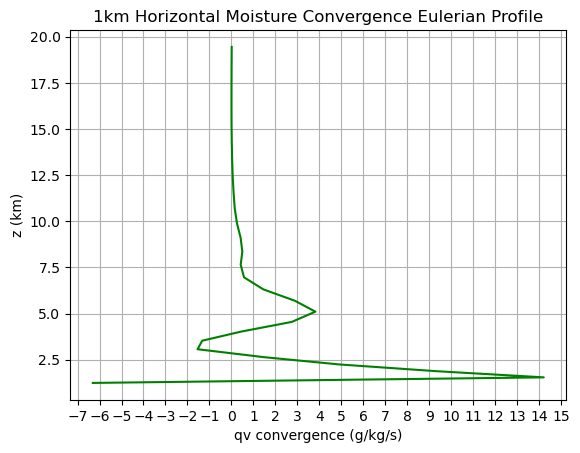

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc')

data2 = np.load(dir+'tracking_algorithms/plots/MFC_output.npz')
one=data2['one']
two=data2['two']

onecopy=np.array(one)[np.where(~np.isnan(one))]
twocopy=np.array(two)[np.where(~np.isnan(one))]

#creates profile storage and adds z column    
zhs=data['zh'].values
profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,2]=zhs

for count,ind in enumerate(twocopy):
    profile_array[ind,0]+=onecopy[count] #adds data to first column
    profile_array[ind,1]+=1 #adds +1 counter to 2nd column

profile=profile_array.copy()
out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no datax
out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter 
plt.plot(out_var[:,0]*1000,out_var[:,1],color='green')
plt.ylabel('z (km)');plt.xlabel('qv convergence (g/kg/s)')
plt.title('1km Horizontal Moisture Convergence Eulerian Profile')
plt.grid()

x_min = int(np.floor(np.min(out_var[:, 0] * 1000)))
x_max = int(np.ceil(np.max(out_var[:, 0] * 1000)))
x_ticks = np.arange(x_min, x_max + 1, 1)  # Range from x_min to x_max inclusive
plt.xticks(x_ticks);

In [ ]:
##############################################################
#Lagrangian parcel distributions

In [56]:
# #Importing Model Data
# import numpy as np
# import matplotlib.pyplot as plt
# import xarray as xr
# check=False
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
# whereCL=whereCL.isel(time=slice(0,len(data['time'])))

# # #Restricts the timesteps of the data from timesteps0 to 140
# # data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))

In [47]:
# def grid_location_floor(x,y,z):
#     zf=data['zf'].values*1000
#     zbins=np.arange(zf.min(),zf.max(),100); dz=zbins[1]-zbins[0]
#     ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0]
#     xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0]

#     which_zf=np.floor(z/dz).astype(int)
#     which_yf=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0].item()
#     which_xf=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0].item()
#     return which_zf,which_yf,which_xf

# def make_storage_arrays():
#     zf=data['zf'].values*1000
#     zbins=np.arange(zf.min(),zf.max(),100); dz=zbins[1]-zbins[0]
#     ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0]
#     xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0]

#     z_arr=np.zeros((len(zbins),2));z_arr[:,1]=zbins
#     y_arr=np.zeros((len(ybins),2));y_arr[:,1]=ybins
#     x_arr=np.zeros((len(xbins),2));x_arr[:,1]=xbins
#     return z_arr,y_arr,x_arr

In [187]:
#testing for a single timestep
# plt.hist(which_xf,bins=len(xbins2));
# plt.hist(which_yf,bins=len(ybins2));
# plt.hist(which_zf,bins=len(zbins2));

In [16]:
# # parcel distrubutions

# #makes arrays to store parcel counts for each x,y,z level
# ############################################################
# [z_arr,y_arr,x_arr]=make_storage_arrays()
# ############################################################

# # for t in np.arange(len(data['time'])):
# for t in [33,34]: #TESTING
# # for t in [0,1]: #TESTING
#     if np.mod(t,50)==0: print(f'timestep {t}')

#     #get the grid locations of all parcels at each timestep
#     #################
#     parcel_t=parcel.isel(time=t)
#     x_t=parcel_t['x'].values;y_t=parcel_t['y'].values;z_t=parcel_t['z'].values
#     [which_zf,which_yf,which_xf]=grid_location_floor(x_t,y_t,z_t)
#     #################
    
#     #z distribution
#     for Nz in np.arange(len(z_arr[:,1])):
#         z_arr[Nz,0]+=len(np.where(which_zf==Nz)[0])
        
#     #y distribution
#     for Ny in np.arange(len(y_arr[:,1])):
#         y_arr[Ny,0]+=len(np.where(which_yf==Ny)[0])
    
#     #x distribution
#     for Nx in np.arange(len(x_arr[:,1])):
#         x_arr[Nx,0]+=len(np.where(which_xf==Nx)[0])
# print('done')

In [15]:
# #z histogram
# counts = z_arr[:, 0]
# x_values = z_arr[:, 1]

# # Plotting the histogram
# plt.barh(x_values, counts, edgecolor='black') 
# plt.xlabel('count');plt.ylabel('z (m)')
# plt.title('histogram of number of parcels in z')

# nt=len(data['time'])
# print(f'std/timestep is {np.std(counts/nt)}')

In [17]:
# #z histogram
# counts = y_arr[:, 0]
# x_values = y_arr[:, 1]

# # Plotting the histogram
# plt.barh(x_values, counts, edgecolor='black')
# plt.ylabel('count');plt.xlabel('y (m)')
# plt.title('histogram of number of parcels in y')

# print(f'std/timestep is {np.std(counts/nt)}')

In [18]:
# #x histogram
# counts = x_arr[:, 0]
# x_values = x_arr[:, 1]

# # Plotting the histogram
# plt.bar(x_values, counts, width=0.01,edgecolor='black')
# plt.ylabel('count');plt.xlabel('x (m)')
# plt.title('histogram of number of parcels in x')

# print(f'std/timestep is {np.std(counts/nt)}')

In [ ]:
##############################################################

In [ ]:
# #TESTING in working order

# #load libraries and data
# import numpy as np
# import matplotlib.pyplot as plt
# import xarray as xr
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc')

# #TESTING
# # dir='/home/air673/koa_scratch/'
# # data=xr.open_dataset(dir+'cm1out_250m.nc')

# #getting qc and interpolated w data
# t=33 #timestep
# # t=33*5 #TESTING
# variable='w'; w_data=data[variable].isel(time=t) #get w data
# w_data=w_data.interp(zf=data['zh']) #interpolation w data z coordinate from zh to zf
# variable='qc'; qc_data=data[variable].isel(time=t) # get qc data
# variable='qi'; qi_data=data[variable].isel(time=t) # get qc data
# qc_plus_qi=qc_data+qi_data

# #find indexes where thresholds are valid
# cloudy_updraft=np.where((w_data>=1) & (qc_plus_qi>=1e-6))# & (qi_data>=1e-9))
# # cloudy_updraft=np.where((w_data>=1))
# print('done using np.where')

# #thi part for each of the (z,y,x) index pairs, gets the corresponding w data
# one,two=[],[]
# for position in zip(*cloudy_updraft):
#     one.append(w_data[position].item()) #append the w data at the position
#     two.append(position[0]) #append the z index at the position
# print('done')

# #plotting
# plt.scatter(one,data['zh'][two]);plt.xlabel('w (m/s)');plt.ylabel('z (m)')

In [ ]:
# # in working order
# #If you interested in seeing the average by z level, use this code below
# ########################################################################

# #creates profile storage and adds z column    
# zhs=data['zh'].values
# profile_array=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
# profile_array[:,2]=zhs

# for count,ind in enumerate(two):
#     profile_array[ind,0]+=one[count] #adds data to first column
#     profile_array[ind,1]+=1 #adds +1 counter to 2nd column

# profile=profile_array.copy()
# out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no datax
# out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter 
# plt.plot(out_var[:,0],out_var[:,1])
# plt.ylabel('z (km)');plt.xlabel('w (m/s)')

# #testing another method

# zero=np.empty_like(w_data.copy())

# for position in zip(*cloudy_updraft):
#     zero[position]=w_data[position].item()
#     # print(w_data[position].item())
# zero[zero == 0] = np.nan
# horizontal_mean = np.nanmean(zero, axis=(1, 2))

# plt.plot(horizontal_mean,np.arange(len(horizontal_mean)));

# #plotting the counts
# plt.plot(profile[:,1],profile[:,2])

# # #investigating eulerian dip between z=4 and z=7 km (looking higher up to check for upper troposphere downdraft)
# zlevs=data['zh'][14:24+1].values

# w_data=data['w'].interp(zf=data['zh']).isel(zh=slice(14,24+1))
# zh_values = w_data['zh'].values
# w_hmean=w_data.mean(dim=('xh','yh')).transpose()
# w_htmean=w_hmean.mean(dim='time')
# plt.plot(w_htmean,zh_values);plt.title('investigating w')
# plt.ylabel('z (km)');plt.xlabel('w (m/s)')

# # plt.axhline(zh_values[np.where(w_htmean==w_htmean.min())[0].item()],color='green',label='minimum w point');plt.legend()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import xarray as xr

# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/' 
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# parcel=parcel.isel(time=times.astype(int))

# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# parcel=parcel.isel(time=np.arange(0,140+1))

# #investigating eulerian dip between z=4 and z=7 km
# # zlevs=data['zh'][14:19+1].values
# zlevs=data['zf'][15:20+1].values

# # w_data=data['w'].interp(zf=data['zh']).isel(zh=slice(14,19+1))
# w_data=data['w'].isel(zf=slice(14,19+1))

# # zh_values = w_data['zh'].values
# zh_values = w_data['zf'].values

# w_hmean=w_data.mean(dim=('xh','yh')).transpose()
# w_htmean=w_hmean.mean(dim='time')
# plt.plot(w_htmean,zh_values);plt.title('investigating w')
# plt.ylabel('z (km)');plt.xlabel('w (m/s)')

# plt.axhline(zh_values[np.where(w_htmean==w_htmean.min())[0].item()],color='green',label='minimum w point');plt.legend()

# print(zh_values[np.where(w_htmean==w_htmean.min())[0].item()])

In [ ]:
#dip in temperature when averaging out t,x,y

# w_hmean=w_data.mean(dim=('xh','yh')).transpose()
# # plt.contourf(w_hmean);plt.ylabel('z (km)');plt.xlabel('time (5 mins)')
# zh_values = w_data['zh'].values
# contour=plt.contourf(w_hmean, levels=20, extent=[0, w_hmean.shape[1], zh_values[0], zh_values[-1]])
# plt.ylabel('z (km)');plt.xlabel('time (5 mins)')
# plt.colorbar(contour, label='w (m/s)');plt.title('investigating w')
# plt.axhline(zh_values[np.where(w_htmean==w_htmean.min())[0].item()],color='green',label='minimum w point');plt.legend()

# #investigating eulerian dip between z=4 and z=7 km
# zlevs=data['zh'][14:19+1].values
# qc_data=data['qc'].isel(zh=slice(14,19+1))
# qc_data=data['qc']

# qc_hmean=qc_data.mean(dim=('xh','yh')).transpose()*1000
# # plt.contourf(w_hmean);plt.ylabel('z (km)');plt.xlabel('time (5 mins)')
# zh_values = w_data['zh'].values
# contour=plt.contourf(qc_hmean, levels=20, extent=[0, w_hmean.shape[1], zh_values[0], zh_values[-1]])
# plt.ylabel('z (km)');plt.xlabel('time (5 mins)')
# plt.colorbar(contour, label='qc (g/kg)');plt.title('investigating qc')
# plt.axhline(zh_values[np.where(w_htmean==w_htmean.min())[0].item()],color='green',label='minimum w point');plt.legend()

In [ ]:
#finding: small updraft at cloud anvil across most of domain

# #investigating eulerian dip between z=4 and z=7 km
# zlevs=data['zh'][14:19+1].values
# qc_data=data['qc'].isel(zh=slice(14,19+1))

# qc_hmean=qc_data.mean(dim=('xh','yh')).transpose()*1000
# # plt.contourf(w_hmean);plt.ylabel('z (km)');plt.xlabel('time (5 mins)')
# zh_values = w_data['zh'].values
# contour=plt.contourf(qc_hmean, levels=20, extent=[0, w_hmean.shape[1], zh_values[0], zh_values[-1]])
# plt.ylabel('z (km)');plt.xlabel('time (5 mins)')
# plt.colorbar(contour, label='qc (g/kg)');plt.title('investigating qc')
# plt.axhline(zh_values[np.where(w_htmean==w_htmean.min())[0].item()],color='green',label='minimum w point');plt.legend()

#finding: region of dip is near top of cloud shown in horizontal average (plotting z vs time)

# qc_htmean=qc_hmean.mean(dim='time')
# plt.plot(qc_htmean,zh_values);plt.title('investigating w')
# plt.ylabel('z (km)');plt.xlabel('qc (g/kg)')
# plt.axhline(zh_values[np.where(w_htmean==w_htmean.min())[0].item()],color='green',label='minimum w point');plt.legend()

# #full qc profile (not subsetting z)

# qc_data=data['qc']

# zh_values = qc_data['zh'].values

# qc_htmean=qc_data.mean(dim=('time','xh','yh')).transpose()

# plt.plot(qc_htmean,zh_values);plt.title('investigating w')
# plt.ylabel('z (km)');plt.xlabel('qc (m/s)')

In [ ]:
#250m

# #Importing Model Data
# #load libraries and data
# import numpy as np
# import matplotlib.pyplot as plt
# import xarray as xr
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

# data = data.isel(time=np.arange(0, 401, 5))
# parcel = parcel.isel(time=np.arange(0, 401, 5))


# #full w profile (not subsetting z) (yes interpolating z)

# w_data=data['w'].interp(zf=data['zh'])
# # w_data=data['w']

# # zh_values = w_data['zh'].values 
# zh_values = w_data['zf'].values

# # w_htmean=w_data.mean(dim=('time','xh','yh')).transpose()
# # w_htmean=w_data.mean(dim='time').mean(dim=('xh','yh')).transpose()
# w_htmean=w_data.mean(dim=('xh','yh')).mean(dim='time')

# w_htmean=w_htmean.transpose()

# plt.plot(w_htmean,zh_values);plt.title('investigating w')
# plt.ylabel('z (km)');plt.xlabel('w (m/s)')
# #ran with pybash.py

# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
# plt.savefig(dir+'tracking_algorithms/plots/250m_w_interp_diptest.jpg', bbox_inches='tight', dpi=300) 

# #full w profile (not subsetting z) (no interpolating z)

# # w_data=data['w'].interp(zf=data['zh'])
# w_data=data['w']

# # zh_values = w_data['zh'].values 
# zh_values = w_data['zf'].values

# w_htmean=w_data.mean(dim=('time','xh','yh')).transpose()

# plt.plot(w_htmean,zh_values);plt.title('investigating w')
# plt.ylabel('z (km)');plt.xlabel('w (m/s)')
# #already ran this

# #full qc profile (not subsetting z)

# qc_data=data['qc']

# zh_values = qc_data['zh'].values

# qc_htmean=qc_data.mean(dim=('time','xh','yh')).transpose()

# plt.plot(qc_htmean,zh_values);plt.title('investigating w')
# plt.ylabel('z (km)');plt.xlabel('qc (m/s)')


#finding small decrease in qc slope at dip point

# #broken down horizontal means
# Nt=len(data['time'])
# for t in np.arange(Nt):
#     w=w_hmean.isel(time=t)
#     plt.plot(w[2:4+1],zh_values[2:4+1],color='b')
# plt.axhline(zh_values[np.where(w_htmean==w_htmean.min())[0].item()],color='green',label='minimum w point');plt.legend()

# #broken down horizontal means
# Nt=len(data['time'])
# for t in np.arange(Nt):
#     qc=qc_hmean.isel(time=t)
#     plt.plot(qc[2:4+1],zh_values[2:4+1],color='b')
# plt.axhline(zh_values[np.where(w_htmean==w_htmean.min())[0].item()],color='green',label='minimum w point');plt.legend()

In [68]:
# ###############
# #Confirm that w values between 10-20 m/s exists in simulation
# import numpy as np
# import matplotlib.pyplot as plt
# import xarray as xr
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc')


# #TESTING
# # dir='/home/air673/koa_scratch/'
# # data=xr.open_dataset(dir+'cm1out_250m.nc')
# where_6km=np.where(data['zf']>=5.9)[0][0]
# where_7km=np.where(data['zf']>=7)[0][0]

# # print(where_7km)
# print(data['zf'][where_6km].item())
# print(data['zf'][where_7km].item())


# t=33
# w_tz=data['w'].isel(time=t,zf=slice(where_6km, where_7km))
# w_tz=w_tz.where(w_tz >= 5, drop=True)
# w_tz_values=w_tz.values.flatten()

# # Plotting histogram
# plt.figure(figsize=(8, 6))
# plt.hist(w_tz_values, bins=30, color='skyblue', edgecolor='black',density=True)#,log=True)
# plt.xlabel("Vertical Velocity (w)")
# plt.ylabel("Normalized Count")
# plt.title("Distribution of Vertical Velocity at 6-7.3 km (filtered > 5 m/s)")
# plt.show()

In [ ]:
#####################

In [ ]:
# #Check the parcel heights distribution from tracked parcel
# #Deep Convective Parcels Profile
# ##### viewing tracking algorithm results
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as colors
# import matplotlib.ticker as ticker
# import matplotlib.cm as cm
# from matplotlib.colors import Normalize
# import matplotlib.gridspec as gridspec
# import xarray as xr
# import os; import time

# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/'
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# parcel=xr.open_dataset(dir+'cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# whereCL=xr.open_dataset(dir+'tracking_algorithms/whereCL_4_0622.nc').load() #***
# whereCL=whereCL.isel(time=slice(0,len(data['time'])))

# # out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking4tundra-7_062217.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# # save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking4tundra-7_062217.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

# out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
# save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

# ###############################################################################
# #remove duplicates
# lst=[]
# unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
# for elem in duplicates:
#     idx = np.where(out_nz[:,0] == elem)[0] 
#     extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
#     lst.extend([x for x in extras])
# mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
# out_nz=out_nz[mask]; 
# placeholder=out_nz.copy(); run=True
# ###############################################################################

# # out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
# # save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
# # print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

# #search for deep convective parcels within lagrangian tracking output     
# ##############################################################
# def threshold(zthresh):
#     out_nz=placeholder.copy()
    
#     deep_out_ind=[]; extendrange=[]
#     times=data['time'].values/(1e9 * 60); times=times.astype(float);
#     for ind in range(len(out_nz)): 
#         #searchs if next most local max goes above zthresh
#         nummins=120; numsteps=int(nummins/times[1])
#         aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
#         aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
#         above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
#         dt=1
#         #takes dabove/dt
#         f=above
#         ddx = (
#                 f[1:  ]
#                 -
#                 f[0:-1]
#             ) / (
#             2 * dt
#         )
#         signs = np.sign(ddx)
#         signs_diff=np.diff(signs)
#         local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
#         if len(local_maxes)==0:
#             local_maxes=[0]
        
#         if np.any(above[local_maxes[0]]>zthresh):
#             extendrange.append(local_maxes[0]) #save to extend xlim of plot later
#             deep_out_ind.append(ind)
    
#     out_nz=out_nz[deep_out_ind,:]
#     # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
#     return out_nz, extendrange
#     # print(out_nz)
# ##############################################################

# convectivelevel=4 #4km
# [out_nz,extendrange]=threshold(convectivelevel)

# print('list of first 10 SBZ parcels'); print(out_nz[:15])
# print(f'there are a total of {len(out_nz)} SBZ parcels and {len(save_nz)} forgotten parcels')

In [ ]:
# def grid_location(x,y,z):
#     xf=data['xf'].values*1000; which_xh=np.searchsorted(xf,x)-1; which_xh=np.where(which_xh == -1, 0, which_xh) #finds which x layer parcel in
#     yf=data['yf'].values*1000; which_yh=np.searchsorted(yf,y)-1; which_yh=np.where(which_yh == -1, 0, which_yh) #finds which y layer parcel in
#     zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in     
#     return which_zh,which_yh,which_xh
    
# def grid_location(x,y,z): #faster
#     #finding xf and yf
#     ybins=data['yf'].values*1000; dy=ybins[1]-ybins[0] #1000
#     xbins=data['xf'].values*1000; dx=xbins[1]-xbins[0] #1000
#     dy=np.round(dy);dx=np.round(dx)

#     #digitizing
#     zf=data['zf'].values*1000; which_zh=np.searchsorted(zf,z)-1; which_zh=np.where(which_zh == -1, 0, which_zh) #finds which z layer parcel in 
#     if which_zh.ndim==0:
#         which_zh=np.array([which_zh])
#     which_yh=np.floor(y/dy).astype(int)+np.where(data['yf']==0)[0]
#     which_xh=np.floor(x/dx).astype(int)+np.where(data['xf']==0)[0]

#     #fixing boundaries
#     which_zh[np.where(which_zh==len(data['zh']))]-=1
#     which_yh[np.where(which_yh==len(data['yh']))]-=1
#     which_xh[np.where(which_xh==len(data['xh']))]-=1
#     return which_zh,which_yh,which_xh

# x=parcel['x'];y=parcel['y'];z=parcel['z']
# which_z,which_y,which_x=grid_location(x,y,z)

In [ ]:
# # np.arange(Np)==>out_nz[:,0]
# # np.arange(Nt)==>out_nz[:,4]
# col4 = out_nz[:, 4].astype(int)
# col5 = out_nz[:, 5].astype(int)
# ranges = [np.arange(start, end + 1) for start, end in zip(col4, col5)]
# indexes = out_nz[:,0]
# indexranges = [np.full_like(r, fill_value=index) for r, index in zip(ranges, indexes)]
# totalelements=sum(len(arr) for arr in ranges)

# w_interp=data['w'].interp(zf=data['zh'])

# zs,ws=[],[]
# for R in np.arange(len(ranges)):
#     if np.mod(R,500)==0: print(f'current trajectory: {R}/{len(ranges)}')
#     for (t,N) in zip(ranges[R],indexranges[R]):
#         z_Nt=parcel['z'].isel(xh=N,time=t)/1000
#         w_Nt=w_interp.isel(time=t,zh=which_z[t,N],yh=which_y[t,N],xh=which_x[t,N])
#         zs.append(z_Nt.item())
#         ws.append(w_Nt.item())


# fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# # Plotting w values
# axs[0].hist(ws, density=True, log=True)
# axs[0].set_ylabel('Normalized Count')
# axs[0].set_xlabel('w (m/s)')
# axs[0].set_title('w values for tracked parcels')

# # Plotting z levels
# axs[1].hist(zs, density=True, log=True)
# axs[1].set_ylabel('Normalized Count')
# axs[1].set_xlabel('z (km)')
# axs[1].set_title('z levels for tracked parcels')

In [ ]:
####################